# Question 6 — Cascade forest versus random forest

CSCE883 Homework 2 · Taylor Belcher 

**AI Disclosure** This Jupyter Notebook was created by OpenAI's Codex with GPT-6 Astra per the homework file instructions and edited by Taylor Belcher.

**Purpose:** implement the cascade diagram in Question 6 and compare it with a standard random forest on UCI Human Activity Recognition (HAR).
AI assistance was used to create the implementation and learning prompts, as permitted by Q6. The interpretation sections are intentionally left for you to write.

Run the cells in order. The first run downloads about 60 MB; training can take several minutes.
Select a Python kernel with the packages below. If imports fail, uncomment and run the installation cell, then restart the kernel.


In [1]:
# Run only if your selected kernel is missing these packages:
# %pip install numpy pandas scikit-learn matplotlib ipykernel


In [2]:
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
from time import perf_counter
import hashlib
import importlib.metadata
import platform
import tempfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

SEED = 42
TREES_PER_FOREST = 100
MAX_LAYERS = 4
N_FOLDS = 3
N_JOBS = 4  # Bound CPU/memory use; change before starting the experiment if needed.

print('Python:', platform.python_version())
for package in ['numpy', 'pandas', 'scikit-learn', 'matplotlib']:
    print(f'{package}: {importlib.metadata.version(package)}')


Python: 3.14.2
numpy: 2.5.3
pandas: 3.0.6
scikit-learn: 1.9.1
matplotlib: 3.11.2


## 1. Load the data

The [UCI dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones)
contains 10,299 windows, 561 numeric features, and six activity labels from 30 participants.
We combine its original train/test files and make the assignment's new 80:10:10 split.
Participant IDs are retained for checking overlap, **not used as features**.
Trees do not require feature standardization here.

The archive is cached in the system temporary directory. Only the required text tables are read;
the download is not extracted into the repository. The loader handles UCI's outer archive containing a nested ZIP.


In [3]:
DATA_URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
CACHE = Path(tempfile.gettempdir()) / 'csce883_q6_data'
CACHE.mkdir(parents=True, exist_ok=True)
archive_path = CACHE / 'uci_har.zip'
if not archive_path.exists():
    print('Downloading UCI HAR...')
    with urlopen(DATA_URL, timeout=120) as response:
        downloaded = response.read()
    # Check the response before caching it.
    with ZipFile(BytesIO(downloaded)) as check:
        assert check.namelist(), 'Empty dataset archive'
    archive_path.write_bytes(downloaded)

archive_bytes = archive_path.read_bytes()
print('Archive SHA-256:', hashlib.sha256(archive_bytes).hexdigest())
archive = ZipFile(BytesIO(archive_bytes))
if not any(name.endswith('/train/X_train.txt') for name in archive.namelist()):
    nested = next(name for name in archive.namelist() if name.endswith('UCI HAR Dataset.zip'))
    nested_bytes = archive.read(nested)
    archive.close()
    archive = ZipFile(BytesIO(nested_bytes))

def read_table(suffix, dtype=float):
    member = next(name for name in archive.namelist() if name.endswith(suffix))
    with archive.open(member) as file:
        return np.loadtxt(file, dtype=dtype)

X = np.vstack([read_table('/train/X_train.txt', np.float32),
               read_table('/test/X_test.txt', np.float32)])
y = np.concatenate([read_table('/train/y_train.txt', int),
                    read_table('/test/y_test.txt', int)])
subjects = np.concatenate([read_table('/train/subject_train.txt', int),
                           read_table('/test/subject_test.txt', int)])
label_rows = read_table('/activity_labels.txt', str)
class_names = dict((int(label), name) for label, name in label_rows)
archive.close()
classes = np.unique(y)
assert X.shape == (10299, 561)
assert len(y) == len(subjects) == len(X)
assert np.isfinite(X).all() and len(classes) == 6
display(pd.Series(y).value_counts().sort_index().rename(index=class_names).to_frame('samples'))


Archive SHA-256: c00b803081a5c797cd5e4b83700a9810b38d53d9d84e01917e090e1fdbc81031


,samples
WALKING,1722
WALKING_UPSTAIRS,1544
WALKING_DOWNSTAIRS,1406
SITTING,1777
STANDING,1906
LAYING,1944


## 2. Make one reproducible 80:10:10 split

Stratification approximately preserves activity proportions. The first split keeps 80% for training;
the remaining 20% is split equally into validation and test sets. Rounding gives 8,239 / 1,030 / 1,030 rows.
Validation selects cascade depth; test labels are used only after model selection.

**Scope of the result:** this is a random split of windows, not a split of participants.
The same people, and potentially overlapping sensor windows, occur across sets. Consequently,
these scores can be optimistic for deployment to unseen people. UCI's original split separates participants;
our numbers are not directly comparable to that benchmark. A participant-disjoint experiment is a useful follow-up.


In [4]:
train_idx, held_idx = train_test_split(
    np.arange(len(y)), test_size=0.20, stratify=y, random_state=SEED)
val_idx, test_idx = train_test_split(
    held_idx, test_size=0.50, stratify=y[held_idx], random_state=SEED)
assert not (set(train_idx) & set(val_idx) or set(train_idx) & set(test_idx)
            or set(val_idx) & set(test_idx))
assert len(set(train_idx) | set(val_idx) | set(test_idx)) == len(y)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]
display(pd.DataFrame([
    {'split': name, 'rows': len(idx), 'fraction': len(idx) / len(y),
     'participants': len(np.unique(subjects[idx]))}
    for name, idx in [('train', train_idx), ('validation', val_idx), ('test', test_idx)]
]))
print('Participants shared by train/test:',
      len(set(subjects[train_idx]) & set(subjects[test_idx])))


,split,rows,fraction,participants
0,train,8239,0.799981,30
1,validation,1030,0.100010,30
2,test,1030,0.100010,30


Participants shared by train/test: 30


## 3. Map the diagram to code

Each layer has **two random forests and two randomized forests**, with independent seeds.
For the blue forests, `ExtraTreesClassifier(max_features=1, bootstrap=False)` uses a randomly chosen
feature and a random threshold at each node, growing without a depth limit. This is a practical
scikit-learn realization of the diagram's completely-random forests, not the authors' original implementation.
Scikit-learn may inspect additional features when needed to find a valid split.

For six classes, each forest returns six probabilities. Concatenating four outputs gives 24 new columns.
Layer 1 receives 561 features; every later layer receives **561 + 24 = 585**.
We keep the original features and only the immediately preceding layer's probability vectors.
At the chosen final layer, average the four probability vectors and select the largest entry.

We use 100 trees per forest and a cap of four layers to keep the homework manageable.
This implements the supplied cascade; it does not implement the separate multi-grained scanning stage of full gcForest.

**Training detail:** to construct the next layer's training features, use three-fold out-of-fold (OOF)
probabilities. Each row's probabilities come from a forest that did not train on that row in that layer.
Then fit each forest on all training rows for validation and later test prediction.
Layerwise OOF reduces direct self-fitting; it is not nested cross-validation of the whole cascade.
We therefore do not treat its training scores as generalization estimates. Independent validation chooses depth.

**Your explanation:** Why pass probabilities instead of just the predicted class? Why retain the original features?


In [5]:
def make_layer(layer_number):
    common = dict(n_estimators=TREES_PER_FOREST, n_jobs=N_JOBS)
    seeds = [SEED + 100 * layer_number + i for i in range(4)]
    return [
        RandomForestClassifier(**common, max_features='sqrt', random_state=seeds[0]),
        RandomForestClassifier(**common, max_features='sqrt', random_state=seeds[1]),
        ExtraTreesClassifier(**common, max_features=1, bootstrap=False, random_state=seeds[2]),
        ExtraTreesClassifier(**common, max_features=1, bootstrap=False, random_state=seeds[3]),
    ]

def checked_proba(model, features):
    # All forests must use the same probability-column/class ordering.
    assert np.array_equal(model.classes_, classes)
    probabilities = model.predict_proba(features)
    assert probabilities.shape == (len(features), len(classes))
    assert np.isfinite(probabilities).all()
    assert np.allclose(probabilities.sum(axis=1), 1.0)
    return probabilities

def fit_layer(train_features, labels, val_features, layer_number):
    folds = StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                           random_state=SEED + layer_number)
    fitted_forests, oof_blocks, val_blocks = [], [], []
    for template in make_layer(layer_number):
        oof = np.zeros((len(labels), len(classes)), dtype=np.float32)
        coverage = np.zeros(len(labels), dtype=int)
        for fit_idx, held_idx in folds.split(train_features, labels):
            fold_model = clone(template)
            fold_model.fit(train_features[fit_idx], labels[fit_idx])
            oof[held_idx] = checked_proba(fold_model, train_features[held_idx])
            coverage[held_idx] += 1
        assert np.all(coverage == 1), 'Every training row needs one OOF prediction'
        full_model = clone(template).fit(train_features, labels)
        fitted_forests.append(full_model)
        oof_blocks.append(oof)
        val_blocks.append(checked_proba(full_model, val_features))
    return fitted_forests, np.hstack(oof_blocks), val_blocks

def predict_cascade(layers, features):
    original = features
    augmented = features
    for forests in layers:
        blocks = [checked_proba(model, augmented) for model in forests]
        averaged = np.mean(blocks, axis=0)
        augmented = np.hstack([original, *blocks])
    return averaged


## 4. Train the standard random forest

Use 400 trees, matching the total trees in one cascade layer. Its other settings are fixed in advance.
The cascade has more total trees and extra OOF fits, so this is **not an equal-compute comparison**.
We report model size and training time alongside accuracy. Neither model trains on validation or test rows.


In [6]:
started = perf_counter()
baseline = RandomForestClassifier(
    n_estimators=4 * TREES_PER_FOREST, max_features='sqrt',
    random_state=SEED, n_jobs=N_JOBS)
baseline.fit(X_train, y_train)
baseline_fit_seconds = perf_counter() - started
baseline_val_accuracy = accuracy_score(y_val, baseline.predict(X_val))
print(f'Baseline validation accuracy: {baseline_val_accuracy:.4f}')
print(f'Baseline training seconds: {baseline_fit_seconds:.1f}')


Baseline validation accuracy: 0.9825
Baseline training seconds: 7.3


## 5. Train cascade candidates and choose depth

Evaluate depths 1 through 4 using validation accuracy. Retain the earliest depth if scores tie.
Depth one is included so the experiment can show when additional layers do not help.
The validation set selects models; its best score is not an unbiased final result.
No retraining on validation is performed, so both models keep the same 80% training set.


Layer 1: validation accuracy = 0.9786


Layer 2: validation accuracy = 0.9864


Layer 3: validation accuracy = 0.9883


Layer 4: validation accuracy = 0.9883


,depth,input_features,validation_accuracy,layer_training_seconds
0,1,561,0.978641,13.335618
1,2,585,0.986408,11.587006
2,3,585,0.988350,11.387671
3,4,585,0.988350,10.919429


Selected depth: 3; total search time: 47.3 seconds


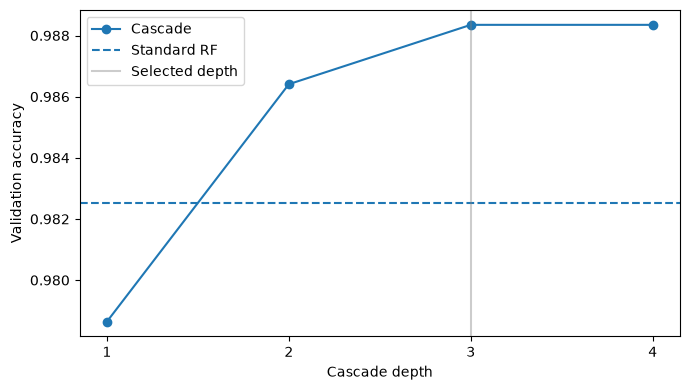

In [7]:
layers, history = [], []
train_features, val_features = X_train, X_val
best_accuracy, best_depth = -np.inf, None
started = perf_counter()
for depth in range(1, MAX_LAYERS + 1):
    layer_started = perf_counter()
    forests, train_blocks, val_blocks = fit_layer(
        train_features, y_train, val_features, depth)
    layers.append(forests)
    val_probabilities = np.mean(val_blocks, axis=0)
    val_prediction = classes[val_probabilities.argmax(axis=1)]
    score = accuracy_score(y_val, val_prediction)
    history.append({'depth': depth, 'input_features': train_features.shape[1],
                    'validation_accuracy': score,
                    'layer_training_seconds': perf_counter() - layer_started})
    if score > best_accuracy:
        best_accuracy, best_depth = score, depth
    print(f'Layer {depth}: validation accuracy = {score:.4f}', flush=True)
    train_features = np.hstack([X_train, train_blocks])
    val_features = np.hstack([X_val, *val_blocks])
    assert train_features.shape[1] == X.shape[1] + 4 * len(classes)

cascade_search_seconds = perf_counter() - started
selected_layers = layers[:best_depth]
history_df = pd.DataFrame(history)
display(history_df)
print(f'Selected depth: {best_depth}; total search time: {cascade_search_seconds:.1f} seconds')
assert np.isclose(accuracy_score(y_val, classes[predict_cascade(
    selected_layers, X_val).argmax(axis=1)]), best_accuracy)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df.depth, history_df.validation_accuracy, 'o-', label='Cascade')
ax.axhline(baseline_val_accuracy, linestyle='--', label='Standard RF')
ax.axvline(best_depth, color='gray', alpha=0.4, label='Selected depth')
ax.set(xlabel='Cascade depth', ylabel='Validation accuracy', xticks=history_df.depth)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Final test comparison

The architecture and selected depth are now fixed. Accuracy measures the fraction classified correctly;
macro F1 gives each activity equal weight. The confusion matrices and per-class reports help locate errors.
Do not change settings in response to these test scores and then reuse the same test set as fresh evidence.


,validation_accuracy,test_accuracy,test_macro_f1,retained_trees,training_and_selection_seconds
model,,,,,
Standard random forest,0.982524,0.980583,0.979824,400,7.266435
Cascade forest,0.988350,0.989320,0.989530,1200,47.263640


Cascade minus standard RF test accuracy: +0.874 percentage points
These are results for one fixed split and seed, not proof of universal superiority.

Standard random forest
                    precision    recall  f1-score   support

           WALKING     0.9942    0.9884    0.9913       172
  WALKING_UPSTAIRS     0.9565    0.9935    0.9747       155
WALKING_DOWNSTAIRS     0.9852    0.9500    0.9673       140
           SITTING     0.9719    0.9719    0.9719       178
          STANDING     0.9738    0.9738    0.9738       191
            LAYING     1.0000    1.0000    1.0000       194

          accuracy                         0.9806      1030
         macro avg     0.9803    0.9796    0.9798      1030
      weighted avg     0.9808    0.9806    0.9806      1030


Cascade forest
                    precision    recall  f1-score   support

           WALKING     0.9942    0.9942    0.9942       172
  WALKING_UPSTAIRS     0.9935    0.9935    0.9935       155
WALKING_DOWNSTAIRS     0.9

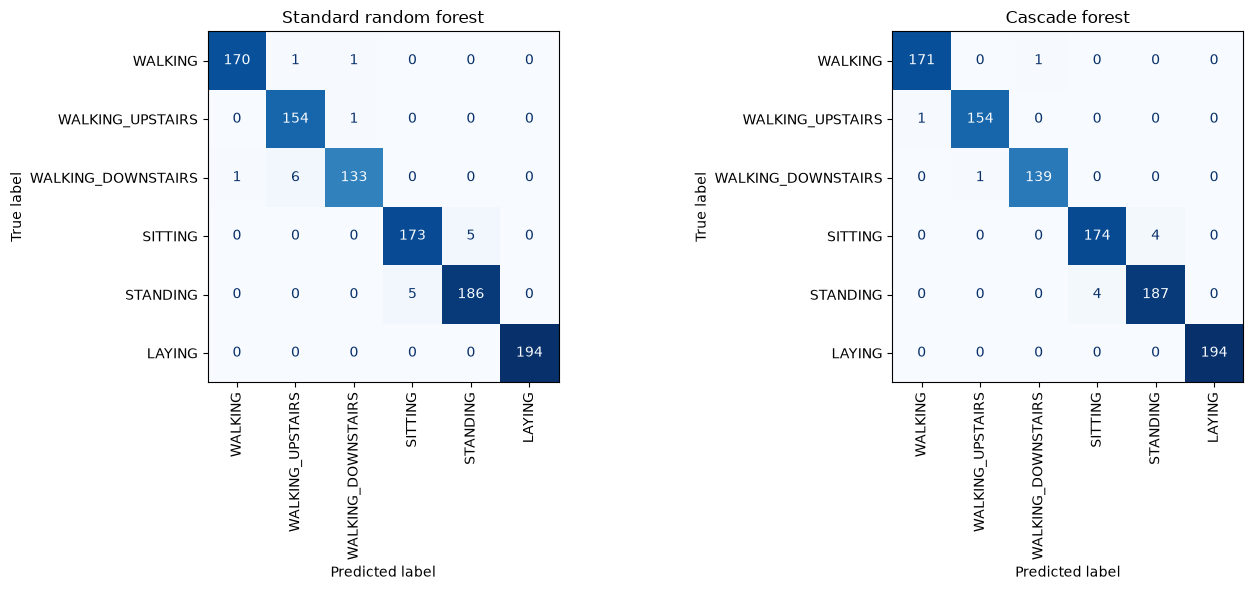

In [8]:
baseline_test_prediction = baseline.predict(X_test)
cascade_test_probabilities = predict_cascade(selected_layers, X_test)
cascade_test_prediction = classes[cascade_test_probabilities.argmax(axis=1)]
predictions = {'Standard random forest': baseline_test_prediction,
               'Cascade forest': cascade_test_prediction}
rows = []
for name, prediction in predictions.items():
    is_cascade = name == 'Cascade forest'
    rows.append({
        'model': name,
        'validation_accuracy': best_accuracy if is_cascade else baseline_val_accuracy,
        'test_accuracy': accuracy_score(y_test, prediction),
        'test_macro_f1': f1_score(y_test, prediction, average='macro'),
        'retained_trees': 4 * TREES_PER_FOREST * (best_depth if is_cascade else 1),
        'training_and_selection_seconds': cascade_search_seconds if is_cascade else baseline_fit_seconds,
    })
results = pd.DataFrame(rows).set_index('model')
display(results)
difference = 100 * (results.loc['Cascade forest', 'test_accuracy']
                    - results.loc['Standard random forest', 'test_accuracy'])
print(f'Cascade minus standard RF test accuracy: {difference:+.3f} percentage points')
print('These are results for one fixed split and seed, not proof of universal superiority.')

names = [class_names[int(label)] for label in classes]
for name, prediction in predictions.items():
    print('\n' + name)
    print(classification_report(y_test, prediction, labels=classes,
                                target_names=names, digits=4, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, prediction) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, prediction, labels=classes, display_labels=names,
        ax=ax, cmap='Blues', colorbar=False, xticks_rotation=90)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 7. Your interpretation — fill this in after reviewing the outputs

- **Architecture:** In your own words, trace one sample through two layers. What are the dimensions at each step?
- **Training:** Explain OOF probabilities and the separate roles of training, validation, and test sets.
- **Results:** Record the selected depth, both test accuracies, macro F1 scores, and the difference in percentage points.
- **Errors:** Which activities are most often confused? Does stacking change those mistakes?
- **Trade-off:** Is the measured gain worth the extra trees and training time in this run?
- **Limitations:** Discuss participant overlap, a single split/seed, the randomized-forest implementation, and unequal compute.
- **Conclusion:** Did the cascade improve this experiment? Use the observed results even if they favor the baseline.

*Write your explanation here and in the LaTeX outline. The code and saved outputs provide evidence, not a prewritten conclusion.*

## References

- Reyes-Ortiz et al. (2013), [Human Activity Recognition Using Smartphones, UCI](https://doi.org/10.24432/C54S4K), CC BY 4.0.
- Zhou and Feng, [Deep Forest, Section 3.1](https://arxiv.org/abs/1702.08835), source of the cascade architecture reproduced in the assignment.
- scikit-learn: [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html),
  [ExtraTreesClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html).
